In [1]:
import tensorflow as tf
print(tf.__version__)

2.19.0


In [ ]:
# More imports
from tensorflow.keras.layers import Input, Dense, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from glob import glob
# What is glob?
# glob is a module in Python that provides a function for finding all the path names matching a specified pattern according to the rules used by the Unix shell. It is used to retrieve files/pathnames from the filesystem based on specified patterns, such as wildcards.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys, os

from tensorflow.keras.applications.vgg16 import VGG16 as PretrainedModel, preprocess_input

# VGG16 is a convolutional neural network architecture that was proposed by the Visual Geometry Group at the University of Oxford. It is a deep learning model that consists of 16 layers, including convolutional layers, pooling layers, and fully connected layers. VGG16 is known for its simplicity and effectiveness in image classification tasks, and it has been widely used as a pre-trained model for transfer learning in various computer vision applications.

In [ ]:
# Read "Food-5K.zip" from current directory and extract it to "Food-5K" folder
# https://drive.google.com/file/d/13x1XOf_vFLebfeC_xRP8fofCLA2UtOU8/view?usp=sharing

import zipfile
with zipfile.ZipFile("/content/Food-5K.zip", "r") as zip_ref:
    zip_ref.extractall("Food-5K")

In [6]:
!ls Food-5K/Food-5K/training

0_0.jpg     0_1387.jpg	0_422.jpg  0_809.jpg   1_1195.jpg  1_230.jpg  1_617.jpg
0_1000.jpg  0_1388.jpg	0_423.jpg  0_80.jpg    1_1196.jpg  1_231.jpg  1_618.jpg
0_1001.jpg  0_1389.jpg	0_424.jpg  0_810.jpg   1_1197.jpg  1_232.jpg  1_619.jpg
0_1002.jpg  0_138.jpg	0_425.jpg  0_811.jpg   1_1198.jpg  1_233.jpg  1_61.jpg
0_1003.jpg  0_1390.jpg	0_426.jpg  0_812.jpg   1_1199.jpg  1_234.jpg  1_620.jpg
0_1004.jpg  0_1391.jpg	0_427.jpg  0_813.jpg   1_119.jpg   1_235.jpg  1_621.jpg
0_1005.jpg  0_1392.jpg	0_428.jpg  0_814.jpg   1_11.jpg    1_236.jpg  1_622.jpg
0_1006.jpg  0_1393.jpg	0_429.jpg  0_815.jpg   1_1200.jpg  1_237.jpg  1_623.jpg
0_1007.jpg  0_1394.jpg	0_42.jpg   0_816.jpg   1_1201.jpg  1_238.jpg  1_624.jpg
0_1008.jpg  0_1395.jpg	0_430.jpg  0_817.jpg   1_1202.jpg  1_239.jpg  1_625.jpg
0_1009.jpg  0_1396.jpg	0_431.jpg  0_818.jpg   1_1203.jpg  1_23.jpg   1_626.jpg
0_100.jpg   0_1397.jpg	0_432.jpg  0_819.jpg   1_1204.jpg  1_240.jpg  1_627.jpg
0_1010.jpg  0_1398.jpg	0_433.jpg  0_81.jpg    1_1205.j

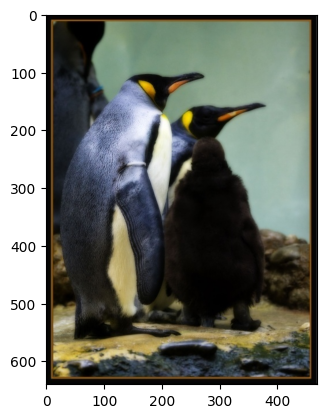

In [7]:
# look at an image for fun
plt.imshow(image.load_img('/content/Food-5K/Food-5K/training/0_0.jpg'))
plt.show()

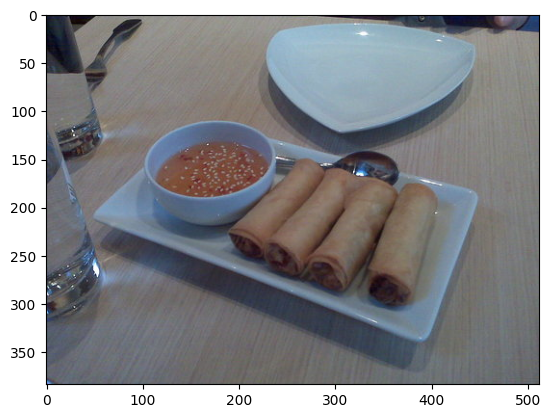

In [8]:
# Food images start with 1, non-food images start with 0
plt.imshow(image.load_img('/content/Food-5K/Food-5K/training/1_1304.jpg'))
plt.show()

In [9]:
!mkdir data

In [5]:
# Make directories to store the data Keras-style
!mkdir data/train
!mkdir data/test
!mkdir data/train/nonfood
!mkdir data/train/food
!mkdir data/test/nonfood
!mkdir data/test/food

The syntax of the command is incorrect.
The syntax of the command is incorrect.
The syntax of the command is incorrect.
The syntax of the command is incorrect.
The syntax of the command is incorrect.
The syntax of the command is incorrect.


In [11]:
# Move the images
# Note: we will consider 'training' to be the train set
#       'validation' folder will be the test set
#       ignore the 'evaluation' set

!mv Food-5K/Food-5K/training/0* data/train/nonfood
!mv Food-5K/Food-5K/training/1* data/train/food
!mv Food-5K/Food-5K/validation/0* data/test/nonfood
!mv Food-5K/Food-5K/validation/1* data/test/food

In [12]:
train_path = 'data/train'
valid_path = 'data/test'

In [13]:
# These images are pretty big and of different sizes
# Let's load them all in as the same (smaller) size
IMAGE_SIZE = [200, 200]

In [14]:
# useful for getting number of files
image_files = glob(train_path + '/*/*.jpg')
valid_image_files = glob(valid_path + '/*/*.jpg')

In [15]:
# useful for getting number of classes
folders = glob(train_path + '/*')
folders

['data/train/food', 'data/train/nonfood']

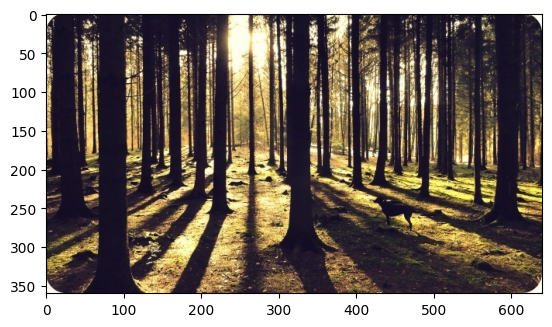

In [16]:
# look at an image for fun
plt.imshow(image.load_img(np.random.choice(image_files)))
plt.show()

In [17]:
# VGG16 is trained on ImageNet dataset which has 1000 classes. We will use the pre-trained weights of VGG16 and fine-tune it for our binary classification task (food vs non-food).
# https://deeplearning.cms.waikato.ac.nz/user-guide/class-maps/IMAGENET/

# Lets load the VGG16 model with pre-trained weights and without the top fully connected layers
pretrained_model = PretrainedModel(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)
# IMAGE_SIZE + [3] - This specifies the input shape of the model. IMAGE_SIZE is a list containing the height and width of the input images (200, 200 in this case), and [3] indicates that the images have 3 color channels (RGB). So, the input shape is (200, 200, 3).

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [18]:
pretrained_model.layers

[<InputLayer name=input_layer, built=True>,
 <Conv2D name=block1_conv1, built=True>,
 <Conv2D name=block1_conv2, built=True>,
 <MaxPooling2D name=block1_pool, built=True>,
 <Conv2D name=block2_conv1, built=True>,
 <Conv2D name=block2_conv2, built=True>,
 <MaxPooling2D name=block2_pool, built=True>,
 <Conv2D name=block3_conv1, built=True>,
 <Conv2D name=block3_conv2, built=True>,
 <Conv2D name=block3_conv3, built=True>,
 <MaxPooling2D name=block3_pool, built=True>,
 <Conv2D name=block4_conv1, built=True>,
 <Conv2D name=block4_conv2, built=True>,
 <Conv2D name=block4_conv3, built=True>,
 <MaxPooling2D name=block4_pool, built=True>,
 <Conv2D name=block5_conv1, built=True>,
 <Conv2D name=block5_conv2, built=True>,
 <Conv2D name=block5_conv3, built=True>,
 <MaxPooling2D name=block5_pool, built=True>]

In [19]:
# freeze pretrained model weights
for layer in pretrained_model.layers:
    layer.trainable = False

In [ ]:
K = len(folders) # number of classes
print(K)

x = Flatten()(pretrained_model.output)
# x = Dense(1024, activation='relu')(x) # can lead to millions of paramters aftr multiplication..which can cause issues
x = Dense(K, activation='softmax')(x)

2


In [21]:
K

2

In [22]:
# create a model object
model = Model(inputs=pretrained_model.input, outputs=x)

In [23]:
# view the structure of the model
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 200, 200, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 200, 200, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 100, 100, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 100, 100, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 100, 100, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 50, 50, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 50, 50, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 50, 50, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 50, 50, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 25, 25, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 25, 25, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 25, 25, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 25, 25, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 12, 12, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │        36,866 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,751,554 (56.27 MB)

 Trainable params: 36,866 (144.01 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
            # DATA AUGMENTATION

# create an instance of ImageDataGenerator
gen_train = ImageDataGenerator(
  rotation_range=20,
  width_shift_range=0.1,
  height_shift_range=0.1,
  shear_range=0.1,
  zoom_range=0.2,
  horizontal_flip=True,
  preprocessing_function=preprocess_input
)

gen_test = ImageDataGenerator(
  preprocessing_function=preprocess_input
)

In [25]:
batch_size = 128

# create generators
train_generator = gen_train.flow_from_directory(
  train_path,
  shuffle=True,
  target_size=IMAGE_SIZE,
  batch_size=batch_size,
)
valid_generator = gen_test.flow_from_directory(
  valid_path,
  target_size=IMAGE_SIZE,
  batch_size=batch_size,
)

Found 3000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


In [26]:
model.compile(
  loss='categorical_crossentropy',
  optimizer='adam',
  metrics=['accuracy']
)

In [27]:
# fit the model
# r = model.fit_generator(
#   train_generator,
#   validation_data=valid_generator,
#   epochs=10,
#   steps_per_epoch=int(np.ceil(len(image_files) / batch_size)),
#   validation_steps=int(np.ceil(len(valid_image_files) / batch_size)),
# )

r = model.fit(
  train_generator,
  validation_data=valid_generator,
  epochs=10,
  steps_per_epoch=int(np.ceil(len(image_files) / batch_size)),
  validation_steps=int(np.ceil(len(valid_image_files) / batch_size)),
)


# training size / batch size
# 3000 / 128 = 24
# no of images in one batch


Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 124s 4s/step - accuracy: 0.9033 - loss: 2.1923 - val_accuracy: 0.9720 - val_loss: 0.6278
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.9773 - loss: 0.5345 - val_accuracy: 0.9740 - val_loss: 0.4432
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.9817 - loss: 0.3642 - val_accuracy: 0.9810 - val_loss: 0.4999
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.9887 - loss: 0.2379 - val_accuracy: 0.9760 - val_loss: 0.5313
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.9887 - loss: 0.1619 - val_accuracy: 0.9780 - val_loss: 0.4909
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.9923 - loss: 0.1279 - val_accuracy: 0.9780 - val_loss: 0.5739
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.9913 - loss: 0.1601 - val_accuracy: 0.9820 - val_loss: 0.4289
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.9920 - loss: 0.1380 - val_accuracy: 0.9780 - val_loss